In [37]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm
import seaborn as sns

from scipy.stats import norm, lognorm

import statsmodels.api as sm
import statsmodels.formula.api as smf


sys.path.append("../")
from xThreat import xThreat

In [38]:
# max_max_error = 0.014
max_max_error = 0.030714285714285715

# Import the data

In [39]:
# Load both old and new error dataframes
df_errors_old = pd.read_csv('../3-calculate-values/bootstrap_errors_normal_xthreat_rerun.csv').rename(columns={'sample_size': 'N'})
df_errors_new = pd.read_csv('../3-calculate-values/bootstrap_errors_normal_xthreat_rerun_extended.csv').rename(columns={'sample_size': 'N'})

# Append the new errors to the old errors
df_errors = pd.concat([df_errors_old, df_errors_new], ignore_index=True)

In [40]:
# Add additional columns
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M/sqrt(N)'] = df_errors['M']*df_errors['1/sqrt(N)']
df_errors['log(M)/sqrt(N)'] = np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M^{3/2}log(M)'] = (df_errors['M']**1.5)*np.log(df_errors['M'])
df_errors['M^{3/2}log(M)/sqrt(N)'] = df_errors['M^{3/2}log(M)']*df_errors['1/sqrt(N)']

In [41]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if '2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [42]:
df_errors.head()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,1.0,1.0,0.005083,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,1.0,1.0,0.003691,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,1.0,1.0,0.006166,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,1.0,1.0,0.004812,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,1.0,1.0,0.006745,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599


In [43]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
count,104000.000000,104000.000000,1.040000e+05,104000.000000,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,...,104000.0,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,1.040000e+05,104000.000000
mean,28.615385,21.538462,8.675000e+05,499.500000,2.974503e+06,0.002411,0.001614,0.018743,0.002998,0.001362,...,1.0,1.000000e+00,0.097886,847.846154,0.001835,11.341260,1.556148,0.011063,2.640548e+05,484.649761
std,17.617988,13.141983,1.240810e+06,288.676378,1.791256e+06,0.002003,0.001451,0.007044,0.002652,0.000662,...,0.0,2.235204e-16,0.136676,934.112527,0.000873,16.215806,2.037898,0.005878,4.069730e+05,858.737253
min,8.000000,6.000000,1.000000e+05,0.000000,6.880420e+05,0.000060,0.000025,0.003151,0.000073,0.000294,...,1.0,1.000000e+00,0.000422,48.000000,0.000500,0.092909,0.024000,0.001936,1.287382e+03,0.643691
25%,14.000000,11.000000,1.600000e+05,249.750000,1.489292e+06,0.000960,0.000556,0.014339,0.001107,0.000801,...,1.0,1.000000e+00,0.010624,154.000000,0.001164,1.089480,0.221524,0.006314,9.626068e+03,12.625974
50%,24.000000,18.000000,3.050000e+05,499.500000,2.464542e+06,0.001771,0.001091,0.018662,0.002057,0.001288,...,1.0,1.000000e+00,0.043155,432.000000,0.001843,4.202079,0.642976,0.010556,5.448810e+04,80.971587
75%,40.000000,30.000000,7.975000e+05,749.250000,4.256791e+06,0.003241,0.002210,0.022536,0.004038,0.001876,...,1.0,1.000000e+00,0.134260,1200.000000,0.002512,14.028312,1.995301,0.015279,2.947290e+05,473.371116
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,0.011238,0.007951,0.067543,0.014307,0.003546,...,1.0,1.000000e+00,1.159943,3072.000000,0.003162,78.008388,9.714517,0.025393,1.367263e+06,4323.663738


In [44]:
print("Possible values of n_x", df_errors['n_x'].unique().tolist())
print("Possible values of n_y", df_errors['n_y'].unique().tolist())
print("Possible values of N", df_errors['N'].unique().tolist())
print("Possible values of M", df_errors['M'].unique().tolist())

Possible values of n_x [16, 32, 40, 48, 56, 64, 8, 10, 12, 14, 20, 24, 28]
Possible values of n_y [12, 24, 30, 36, 42, 48, 6, 8, 9, 11, 15, 18, 21]
Possible values of N [4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]
Possible values of M [192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]


# General result inspection

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.275191), np.float64(0.194905), np.float64(0.496005), np.float64(1.0)), (np.float64(0.212395), np.float64(0.359683), np.float64(0.55171), np.float64(1.0)), (np.float64(0.151918), np.float64(0.500685), np.float64(0.557587), np.float64(1.0)), (np.float64(0.12478), np.float64(0.640461), np.float64(0.527068), np.float64(1.0)), (np.float64(0.311925), np.float64(0.767822), np.float64(0.415586), np.float64(1.0)), (np.float64(0.616293), np.float64(0.852709), np.float64(0.230052), np.float64(1.0)), (np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0))]


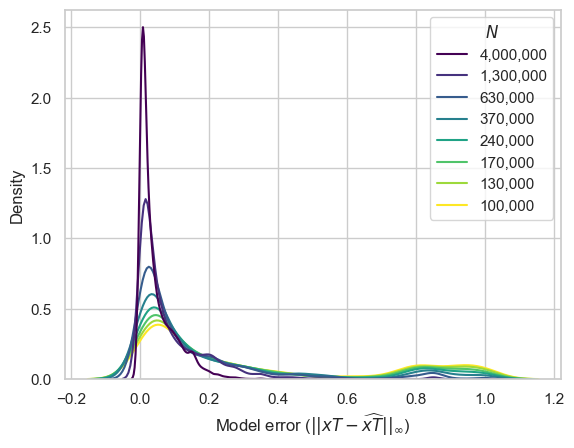

In [45]:
cmap = 'viridis'

ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='1/sqrt(N)', palette=cmap)

# Get the unique hue values ('1/sqrt(N)')
hue_levels = np.unique(df_errors['1/sqrt(N)'])
rounded_hue_levels = [f"{int(1/level**2):,}" for level in hue_levels]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, rounded_hue_levels, title=r"$N$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

plt.show()

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.279574), np.float64(0.170599), np.float64(0.479997), np.float64(1.0)), (np.float64(0.257322), np.float64(0.25613), np.float64(0.526563), np.float64(1.0)), (np.float64(0.21621), np.float64(0.351535), np.float64(0.550627), np.float64(1.0)), (np.float64(0.190631), np.float64(0.407061), np.float64(0.556089), np.float64(1.0)), (np.float64(0.149039), np.float64(0.508051), np.float64(0.55725), np.float64(1.0)), (np.float64(0.121148), np.float64(0.592739), np.float64(0.544641), np.float64(1.0)), (np.float64(0.137339), np.float64(0.662252), np.float64(0.515571), np.float64(1.0)), (np.float64(0.20803), np.float64(0.718701), np.float64(0.472873), np.float64(1.0)), (np.float64(0.421908), np.float64(0.805774), np.float64(0.35191), np.float64(1.0)), (np.float64(0.636902), np.float64(0.856542), np.float64(0.21662), np.float64(1.0)), (np.float64(0.83527), np.float64(0.886029), np.float64(0.102646), np.f

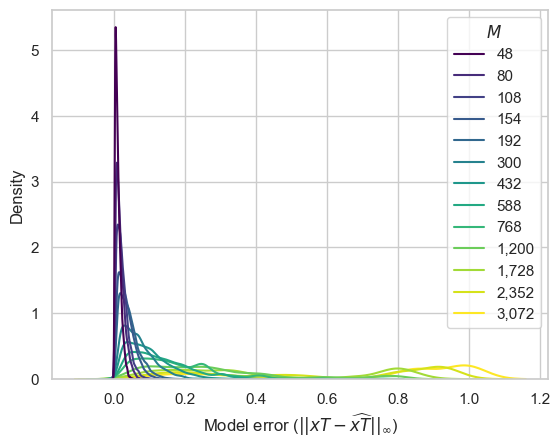

In [46]:
cmap = 'viridis'


ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue=np.log(df_errors['M']), palette=cmap)

# Get the unique hue values ('M')
hue_levels = np.unique(np.log(df_errors['M']))
labels = [f"{int(level):,}" for level in np.unique(df_errors['M'])]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, labels, title=r"$M$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

plt.show()

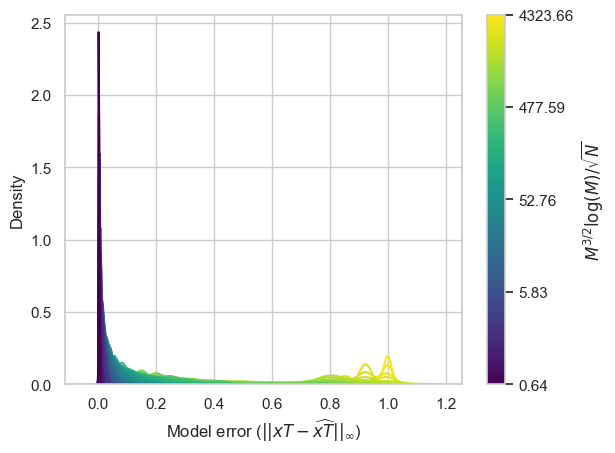

In [48]:
fig, ax = plt.subplots()
norm = plt.Normalize(np.log(df_errors['M^{3/2}log(M)/sqrt(N)'].min()), np.log(df_errors['M^{3/2}log(M)/sqrt(N)'].max()))
sm_ = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm_.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_inf_norm', 
    hue=np.log(df_errors['M^{3/2}log(M)/sqrt(N)']), 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

# Add a color bar with the correct ticks of 'M^{3/2}log(M)/sqrt(N)'
min_val = np.min(np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])))
max_val = np.max(np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])))
ticks_positions = np.linspace(min_val, max_val, num=5)
ticks_values = np.exp(ticks_positions)
# ticks_position = np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)']))
# ticks_values = np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])

# Add a color bar with the correct ticks at the correct places
cbar = plt.colorbar(sm_, ax=ax, ticks=ticks_positions)
cbar.set_ticklabels([f"{val:.2f}" for val in ticks_values])
cbar.set_label(r"$M^{3/2}\log(M)/\sqrt{N}$")

plt.show()

# Subparts of Model

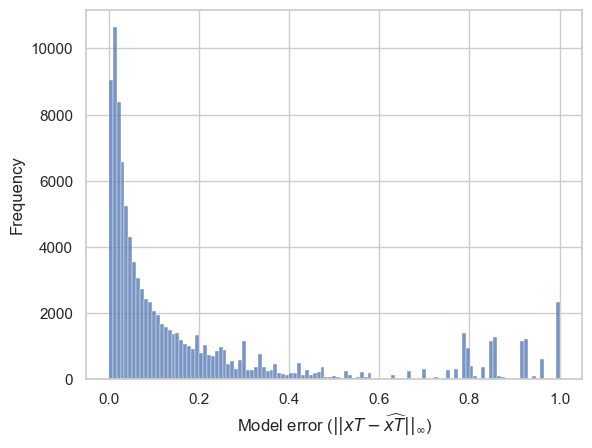

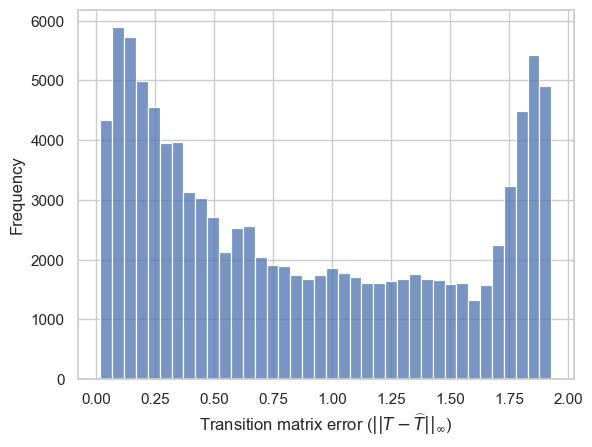

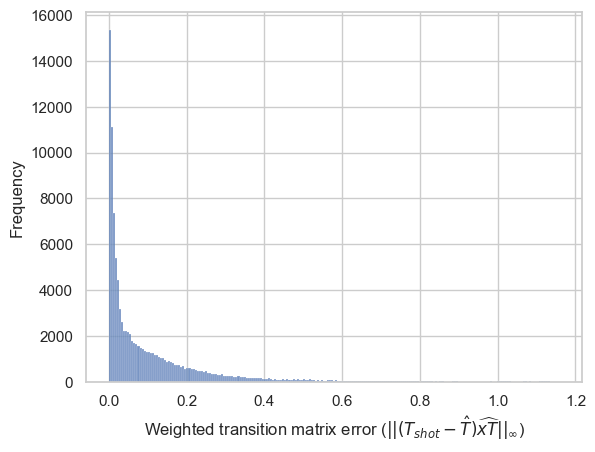

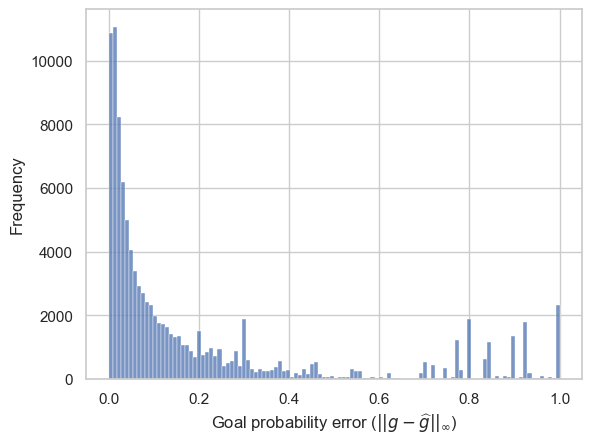

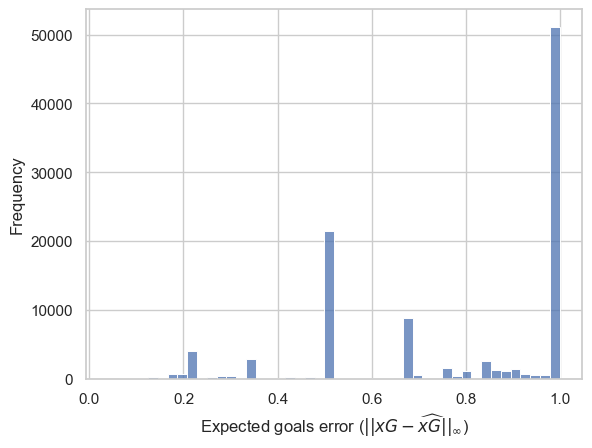

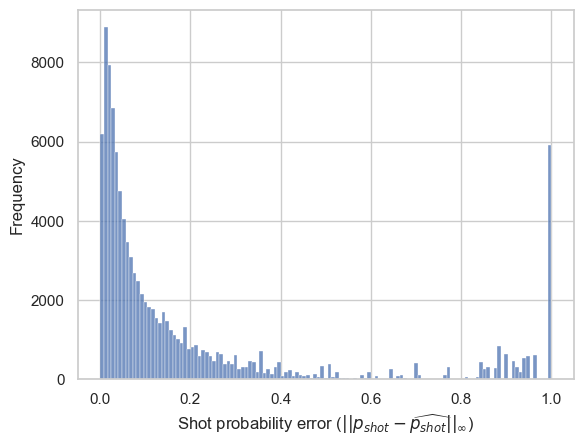

In [49]:
# Plot histograms of the errors
error_columns = ['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 'weighted_transition_matrix_error_inf_norm',
                 'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']
error_labels = [r'Model error ($||xT-\widehat{xT}||_\infty$)', 
                r'Transition matrix error ($||T-\widehat{T}||_\infty$)', 
                r'Weighted transition matrix error ($||(T_{shot}-\hat{T})\widehat{xT}||_\infty$)',
                r'Goal probability error ($||g-\widehat{g}||_\infty$)', 
                r'Expected goals error ($||xG-\widehat{xG}||_\infty$)', 
                r'Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$)', 
                r'Weighted shot probability error ($||w_{shot}-\widehat{w_{shot}}||_\infty$)']

for error_col, error_label in zip(error_columns, error_labels):
    plt.figure()
    sns.histplot(df_errors[error_col], bins='auto', kde=False)
    # plt.title(f"Histogram of {error_label}")
    plt.xlabel(error_label)
    plt.ylabel("Frequency")
    plt.show()

In [50]:
# Scatterplot of the errors vs the model error with histogram of the errors

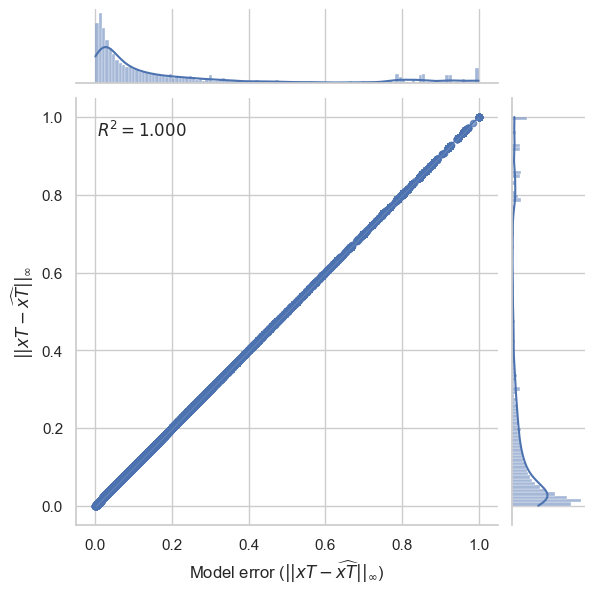

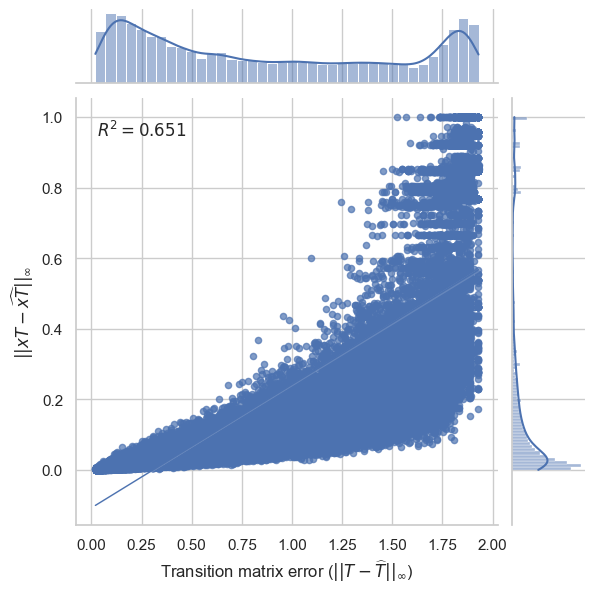

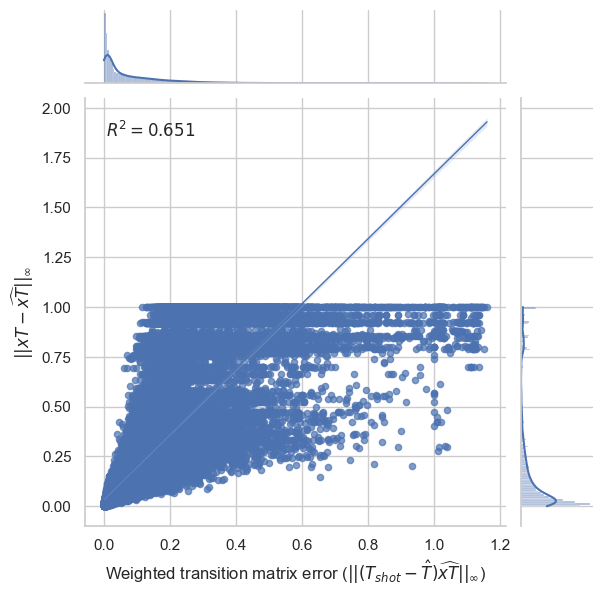

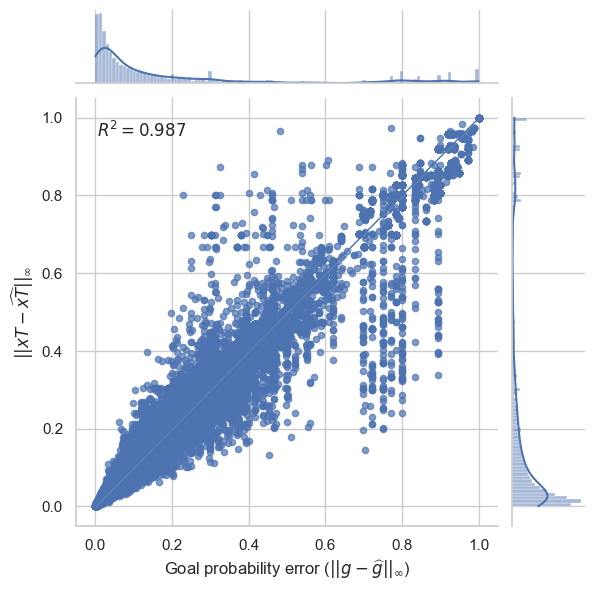

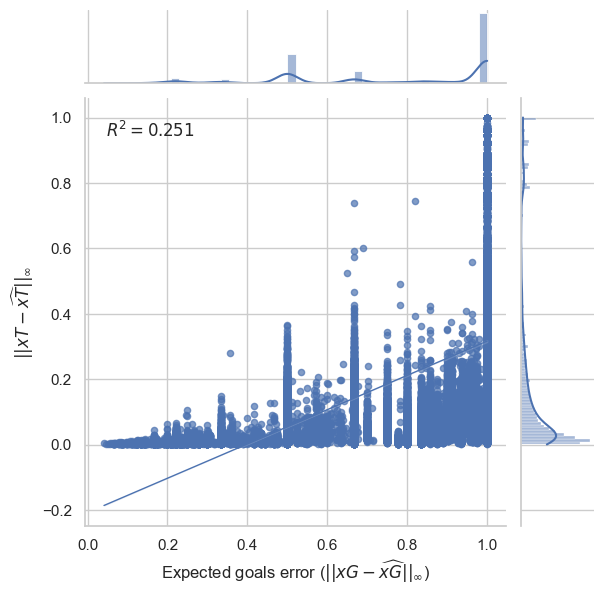

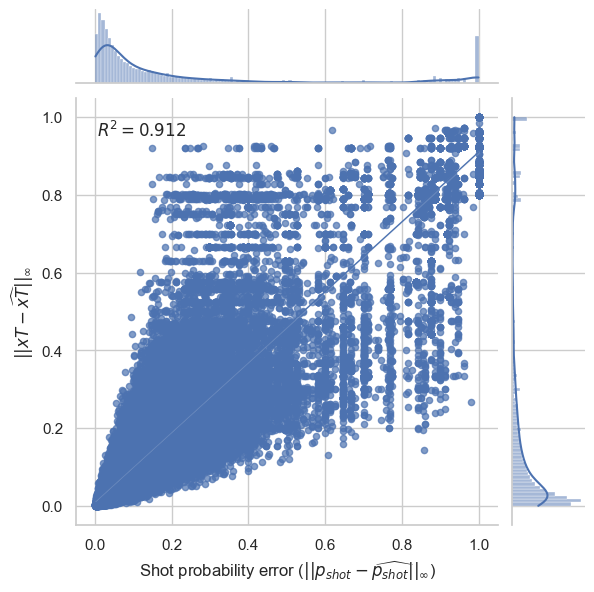

In [51]:
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

for col, label in zip(error_columns, error_labels):

    x = df_errors[col].values
    y = df_errors['xT_error_inf_norm'].values

    # Compute R^2
    coeffs = np.polyfit(x, y, 1)
    y_pred = np.polyval(coeffs, x)
    r2 = r2_score(y, y_pred)

    # Create jointplot with regression
    g = sns.jointplot(
        data=df_errors,
        x=col,
        y='xT_error_inf_norm',
        kind="reg",        # scatter + regression line
        height=6,
        scatter_kws=dict(s=20, alpha=0.7),
        line_kws=dict(linewidth=1)
    )

    # Add R^2 annotation
    g.ax_joint.text(
        0.05, 0.95,
        f"$R^2 = {r2:.3f}$",
        transform=g.ax_joint.transAxes,
        ha='left', va='top'
    )

    # Title formatting
    # g.ax_joint.set_title(label)
    g.ax_joint.set_ylabel(r'$||xT-\widehat{xT}||_\infty$')
    g.ax_joint.set_xlabel(label)

    plt.show()


## Combine histogram with plots

In [52]:
y_col = 'xT_error_inf_norm'
x_cols = ['transition_matrix_error_inf_norm', 'weighted_transition_matrix_error_inf_norm',
                            'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']
y_label = r'Model error ($||xT-\widehat{xT}||_\infty$)'
x_labels = [r'Transition matrix error ($||T-\widehat{T}||_\infty$)', 
            r'Weighted transition matrix error ($||(T-\hat{T})\widehat{xT}||_\infty$)',
            r'Goal probability error ($||g-\widehat{g}||_\infty$)', 
            r'Expected goals error ($||xG-\widehat{xG}||_\inf$)', 
            r'Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$)',
            ]

R^2 between Transition matrix error ($||T-\widehat{T}||_\infty$) and model error: 0.6510
R^2 between Weighted transition matrix error ($||(T-\hat{T})\widehat{xT}||_\infty$) and model error: 0.6511
R^2 between Goal probability error ($||g-\widehat{g}||_\infty$) and model error: 0.9870
R^2 between Expected goals error ($||xG-\widehat{xG}||_\inf$) and model error: 0.2507
R^2 between Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$) and model error: 0.9124


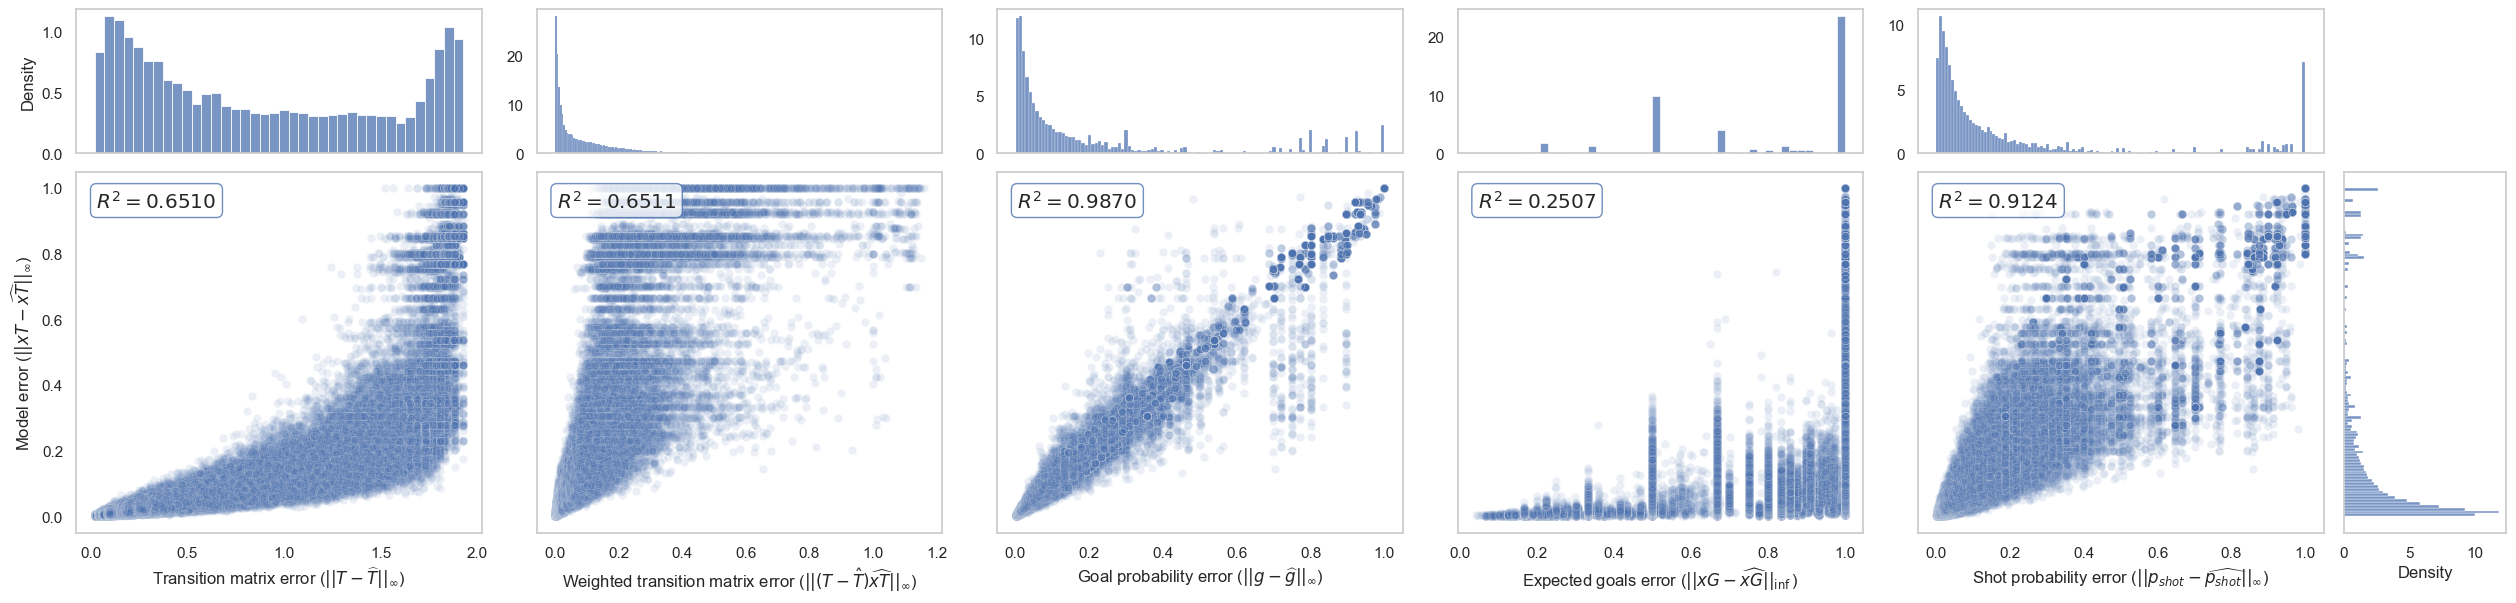

In [53]:
# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 7), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    # Compute R^2 
    coeffs = np.polyfit(x, y, 1) 
    y_pred = np.polyval(coeffs, x) 
    r2 = r2_score(y, y_pred) 
    print(f"R^2 between {label} and model error: {r2:.4f}")
    ax = axes[idx] 
    # Scatter plot 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.1) 
    ax.grid(False)
    
    # # Regression line 
    # ax.plot(x, y_pred, color='red', linewidth=1) 

    # R^2 annotation 
    ax.text( 0.05, 0.95, 
            f"$R^2 = {r2:.4f}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hist_color)
            ) 

    # Axis labels 
    ax.set_xlabel(label) 
    if idx == 0: 
        ax.set_ylabel(r'Model error ($||xT-\widehat{xT}||_\infty$)') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.40]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    if idx > 0:
        ax_hist_above.set_ylabel('')

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.40, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.grid(False) 
plt.tight_layout() 
plt.show()

In [54]:
# # Define the plot
# g = sns.PairGrid(df_errors[['xT_error_inf_norm', 'transition_matrix_error_inf_norm', 
#                             'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']])

# # Map different plots to different sections of the grid
# def corrfunc(x, y, **kwargs):
#     r = np.corrcoef(x, y)[0, 1]
#     ax = plt.gca()
#     ax.annotate(f'r = {r:.2f}', xy=(0.5, 0.5), xycoords=ax.transAxes, 
#                 ha="center", va="center", fontsize=12, fontweight="bold")

# g.map_upper(corrfunc)
# g.map_lower(sns.kdeplot, fill=True)
# g.map_diag(sns.histplot)

# # Rename axis labels
# new_labels = {
#     'xT_error_inf_norm': 'Maximal xT Error',
#     'transition_matrix_error_inf_norm': 'Maximal Transition Matrix Error',
#     'g_error_inf_norm': 'Maximal g Error',
#     'xG_error_inf_norm': 'Maximal xG Error',
#     'prob_shot_error_inf_norm': 'Maximal Probability Shot Error'
# }

# # Update axis labels
# for ax in g.axes.flatten():
#     if ax is not None:  # Some may be empty
#         xlabel = ax.get_xlabel()
#         ylabel = ax.get_ylabel()
#         if xlabel in new_labels:
#             ax.set_xlabel(new_labels[xlabel])
#         if ylabel in new_labels:
#             ax.set_ylabel(new_labels[ylabel])

# plt.show()

# OLS Modeling

## Finding the cut-off point

In [55]:
a = df_errors['Mlog(M)/sqrt(N)'].values
b = df_errors['M^{3/2}log(M)/sqrt(N)'].values

old_sel = (a < 15)

# Candidate C values = possible thresholds on b
candidates = np.unique(b)

best_C = None
best_error = np.inf

for C in candidates:
    new_sel = (b < C)
    error = np.sum(new_sel != old_sel)  # number of mismatches
    if error < best_error:
        best_error = error
        best_C = C

print("Optimal C =", best_C)
print("Minimal mismatches =", best_error)
print("Total samples =", len(a))
print("Mismatch rate =", best_error/len(a))


Optimal C = 601.612969165312
Minimal mismatches = 2000
Total samples = 104000
Mismatch rate = 0.019230769230769232


In [56]:
new_sel = (b < best_C)
TP = np.sum(new_sel & old_sel)
TN = np.sum(~new_sel & ~old_sel)
FP = np.sum(new_sel & ~old_sel)
FN = np.sum(~new_sel & old_sel)

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")


TP=78000, TN=24000, FP=1000, FN=1000


78.00838822064868
[ 0.     9.875 19.75  29.625 39.5   49.375 59.25  69.125 79.   ]


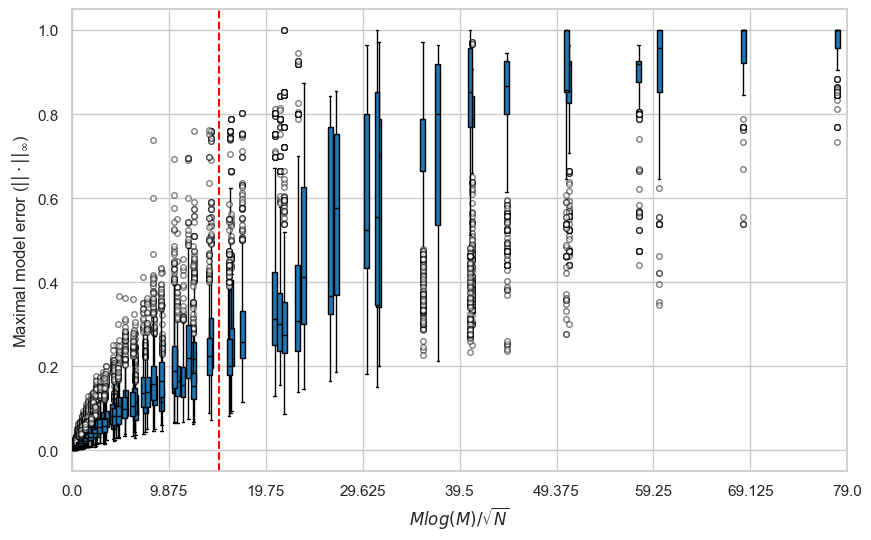

4323.663738071074
[   0.   540.5 1081.  1621.5 2162.  2702.5 3243.  3783.5 4324. ]


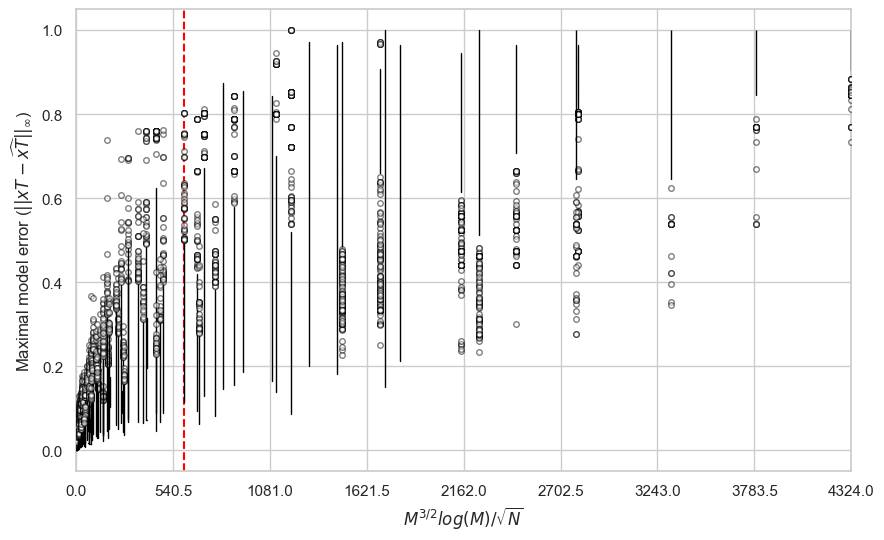

In [57]:
plt.figure(figsize=(10, 6))

color = sns.color_palette("tab10")[0]

vals = df_errors['Mlog(M)/sqrt(N)'].unique().tolist()
data_listed = [
    df_errors[df_errors['Mlog(M)/sqrt(N)'] == val]['xT_error_inf_norm'].tolist()
    for val in vals
]

for idx, (val, data_points) in enumerate(zip(vals, data_listed)):
    plt.boxplot(
        data_points,
        positions=[val],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        # boxprops=dict(facecolor='lightblue', color='black', linewidth=1),
        boxprops=dict(facecolor=color, color='black', linewidth=1),
        # boxprops=dict(facecolor='#4C72B0', color='black'),
        capprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        flierprops=dict(markerfacecolor='white', marker='o', markersize=4, alpha=0.5),
        zorder=idx,
    )

plt.axvline(x=15, color='red', linestyle='--', label='Threshold at 15')

plt.grid(True)
plt.xlim(0, np.ceil(max(vals)))
n_ticks = 9
ticks = np.linspace(0.0, np.ceil(max(vals)), n_ticks)
print(max(vals))
print(ticks)
plt.xticks(ticks, labels=ticks)
plt.xlabel(r'$Mlog(M)/\sqrt{N}$')
plt.ylabel(r'Maximal model error ($||\cdot||_{\infty}$)')
plt.show()



plt.figure(figsize=(10, 6))

vals = df_errors['M^{3/2}log(M)/sqrt(N)'].unique().tolist()
data_listed = [
    df_errors[df_errors['M^{3/2}log(M)/sqrt(N)'] == val]['xT_error_inf_norm'].tolist()
    for val in vals
]

for idx, (val, data_points) in enumerate(zip(vals, data_listed)):
    plt.boxplot(
        data_points,
        positions=[val],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        # boxprops=dict(facecolor='lightblue', color='black', linewidth=1),
        boxprops=dict(facecolor=color, color='black', linewidth=1),
        # boxprops=dict(facecolor='#4C72B0', color='black'),
        capprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        flierprops=dict(markerfacecolor='white', marker='o', markersize=4, alpha=0.5),
        zorder=idx,
    )
plt.axvline(x=602.35, color='red', linestyle='--', label='Threshold at 602.35')
plt.grid(True)
plt.xlim(0, np.ceil(max(vals)))
n_ticks = 9
ticks = np.linspace(0.0, np.ceil(max(vals)), n_ticks)
print(max(vals))
print(ticks)
plt.xticks(ticks, labels=ticks)
plt.xlabel(r'$M^{3/2}log(M)/\sqrt{N}$')
plt.ylabel(r'Maximal model error ($||xT-\widehat{xT}||_{\infty}$)')
plt.show()

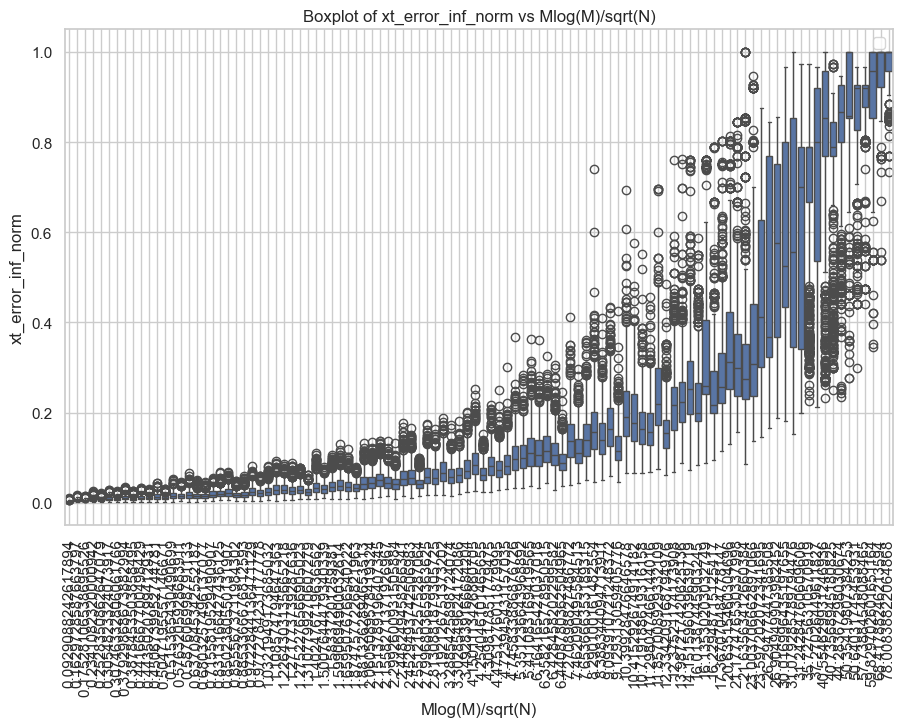

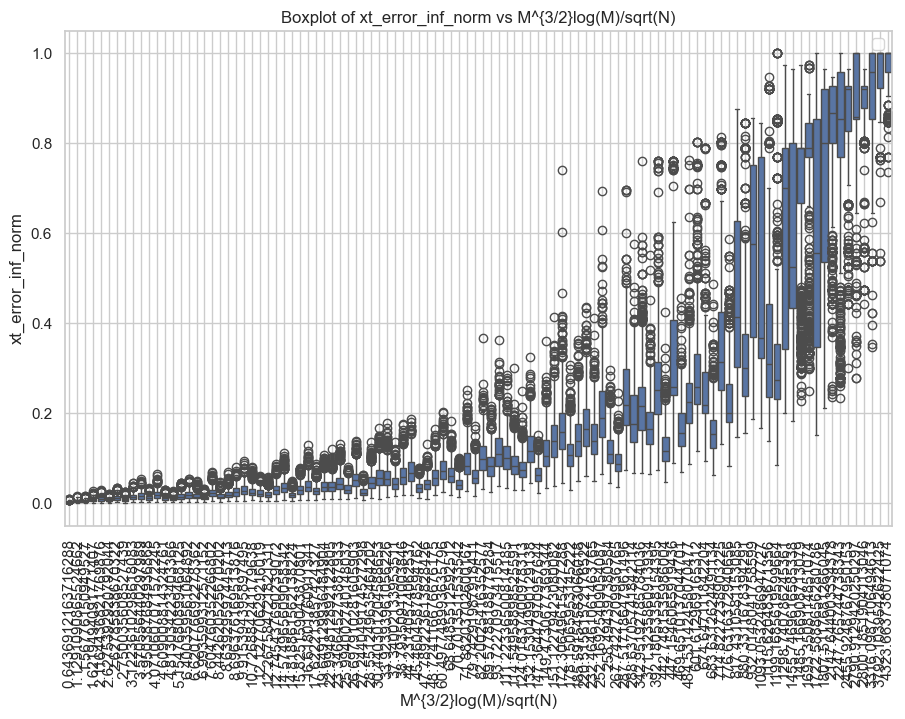

In [58]:
# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mlog(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()



# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='M^{3/2}log(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M^{3/2}log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs M^{3/2}log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()

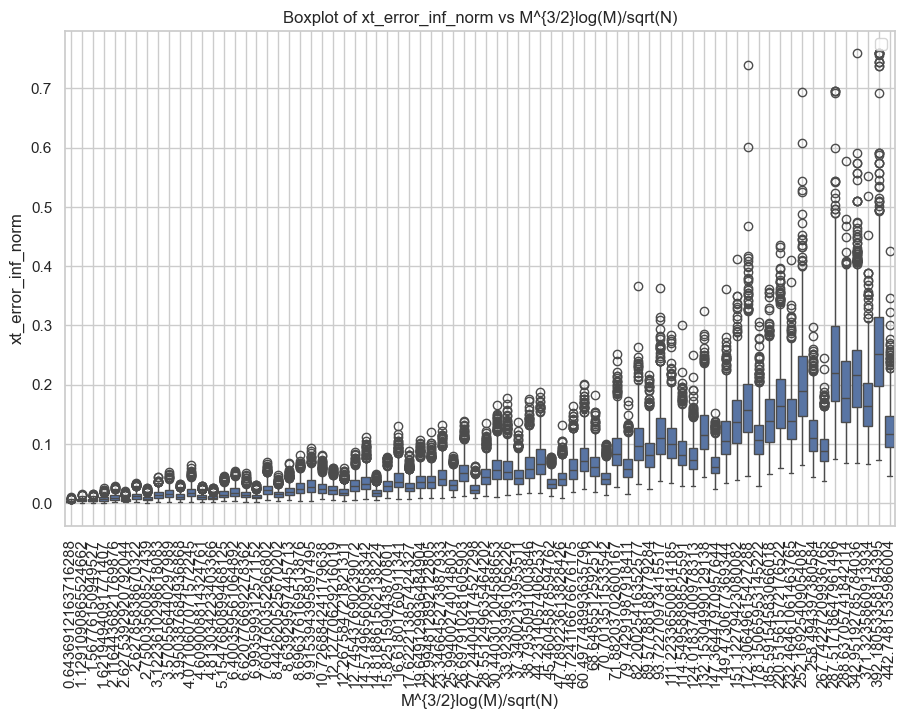

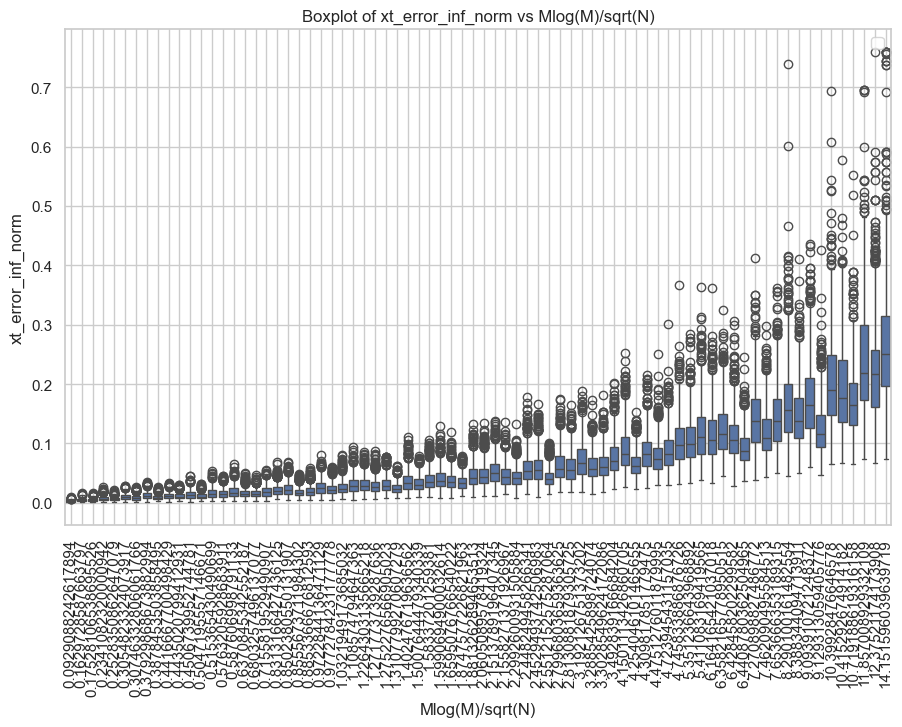

In [59]:
df_errors_ols = df_errors[df_errors['M^{3/2}log(M)/sqrt(N)'] < 445].copy()
# df_errors_ols = df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15].copy()


# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='M^{3/2}log(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M^{3/2}log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs M^{3/2}log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()


# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mlog(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('Mlog(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs Mlog(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()

# Applying OLS to the filtered dataset

In [70]:
# df_errors_ols = df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15].copy()
df_errors_ols = df_errors[df_errors['M^{3/2}log(M)/sqrt(N)'] < 445].copy()
df_errors_ols['sqrt(M)log(M)/sqrt(N)'] = df_errors_ols['log(M)/sqrt(N)'] * np.sqrt(df_errors_ols['M'])

                            OLS Regression Results                            
Dep. Variable:      xT_error_inf_norm   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 2.416e+05
Date:                 vr, 16 jan 2026   Prob (F-statistic):               0.00
Time:                        15:21:51   Log-Likelihood:                -42284.
No. Observations:               76000   AIC:                         8.457e+04
Df Residuals:                   75997   BIC:                         8.460e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.0916      0.017   -121.

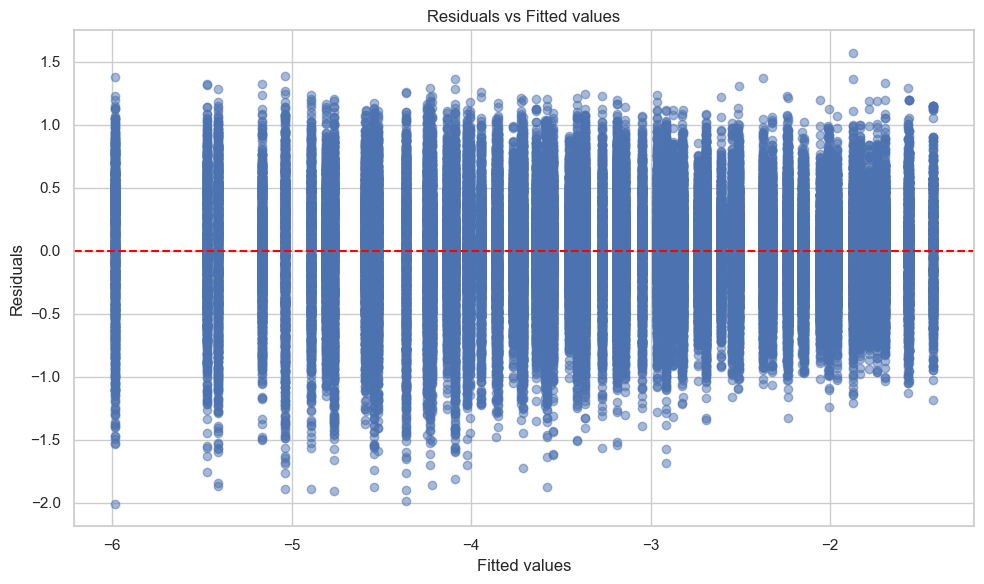

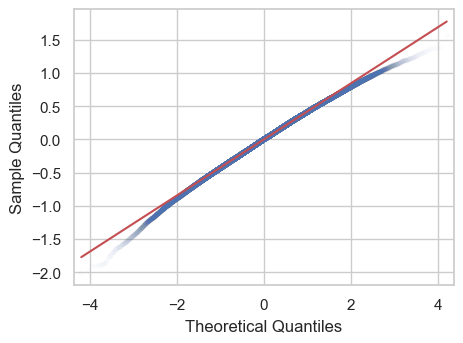

In [82]:
# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
Y = np.log(df_errors_ols['xT_error_inf_norm'])
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot the QQ plot of the residuals
# fig, ax = plt.subplots(figsize=(6.4, 4.8))
fig, ax = plt.subplots(figsize=(4.8, 3.6))
# fig, ax = plt.subplots(figsize=(3.2, 2.4))
sm.qqplot(results.resid, line='s', ax = ax, alpha=0.01, markersize=3)
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


In [84]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(1/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")
print(f"Variance residuals={results.mse_resid}")
print(f"beta={beta}")

c=-2.0915784326697198
power=1.0099919011379082
std_residuals=0.4220842476334173
Variance residuals=0.1781551121002679
beta=1.0266672599410456


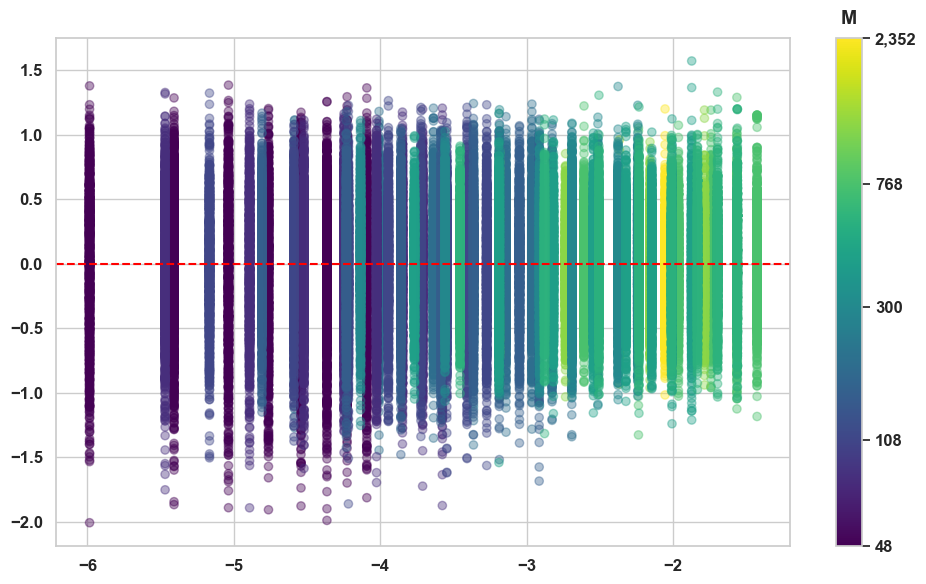

In [127]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Plot
plt.figure(figsize=(10,6))
sc = plt.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['M']), cmap='viridis', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['M'], [0.0, 0.25, 0.6, 0.92, 1.0]))
cbar.set_ticks(ticks)

# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("M", weight='bold', pad=10, fontsize=14)
fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)
    
plt.tight_layout()
plt.show()


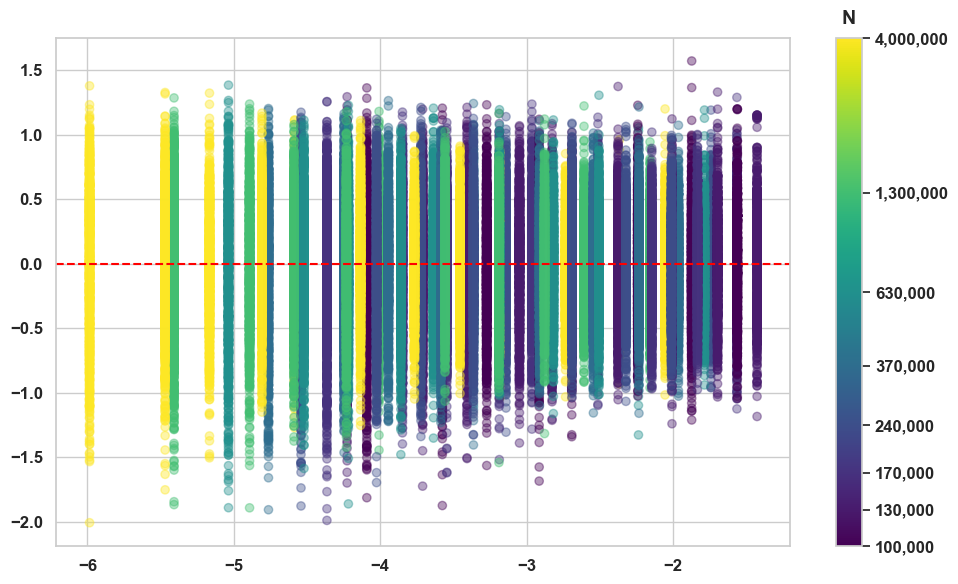

In [128]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Plot
plt.figure(figsize=(10,6))
sc = plt.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['N']), cmap='viridis', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['N'], [0.0, 0.3, 0.5, 0.6, 0.75, 1.0]))
ticks = np.log(df_errors_ols['N'].unique().tolist())
cbar.set_ticks(ticks)

# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("N", weight='bold', pad=10, fontsize=14)
fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

plt.tight_layout()
plt.show()


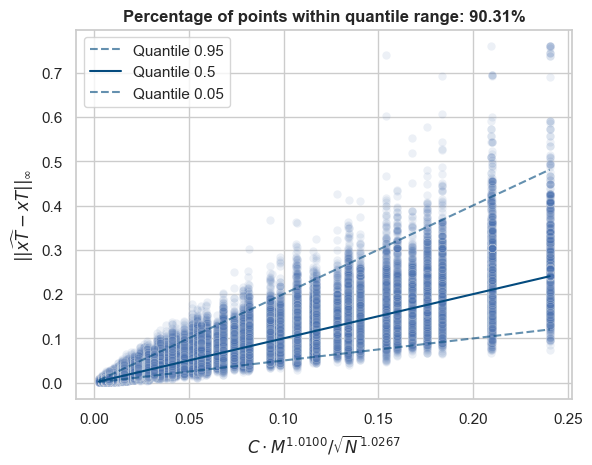

In [76]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

xs = np.exp(c)*df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

sns.scatterplot(
    x=xs,
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
    alpha=0.1,
)

# Add quantiles
quantiles = [0.05, 0.5, 0.95]
linestyles = ['--', '-', '--']
colors = ['blue', 'darkblue', 'blue']
colors = ["#044b7e9d", "#044b7e", '#044b7e9d']


xs_plot = np.linspace(xs.min(), xs.max(), 1000)
for i, q in enumerate(quantiles[::-1]):
    quantile = lognorm.ppf(q, s=std_residuals, scale=xs_plot)
    plt.plot(xs_plot, quantile, label=f'Quantile {q}', linestyle=linestyles[i], color=colors[i])

ax.set_xlabel(r'$C\cdot M^{%.4f} / \sqrt{N}^{%.4f}$' % (power, beta), weight='bold')
ax.set_ylabel(r'$||\widehat{xT} - xT||_{\infty}$', weight='bold')

# Calculate the number of points within the quantile range
within_quantile = df_errors_ols[
    (df_errors_ols['xT_error_inf_norm'] >= lognorm.ppf(0.05, s=std_residuals, scale=xs)) &
    (df_errors_ols['xT_error_inf_norm'] <= lognorm.ppf(0.95, s=std_residuals, scale=xs))
]

within_quantile_count = len(within_quantile)
plt.title(f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%', weight='bold')
# Make it an annotation
# plt.annotate(
#     f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%',
#     xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, ha='left', va='top',
#     bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
# )

plt.legend()

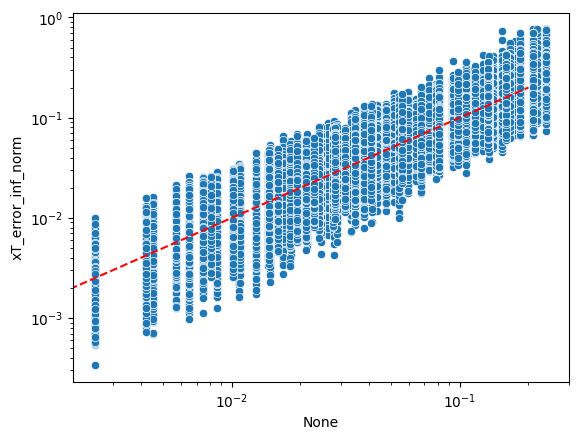

In [170]:
fig, ax =  plt.subplots(figsize=(6.4, 4.8))
ax.set(xscale='log', yscale='log')
sns.scatterplot(
    x=np.exp(results.fittedvalues),
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
)
# Add line y=x
plt.plot([0, 0.2], [0, 0.2], color='red', linestyle='--', label='y=x')